<a href="https://colab.research.google.com/github/shreejanya/Breast-cancer-classification-/blob/main/Breast_Cancer_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Importing necessary libraries
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt

In [ ]:
# Loading the dataset
dataset = pd.read_csv('data.csv')
dataset.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


In [ ]:
# Checking the column names in the dataset
dataset.columns



Index(['id', 'diagnosis', 'radius_mean', 'texture_mean', 'perimeter_mean',
       'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean',
       'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean',
       'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se',
       'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se',
       'fractal_dimension_se', 'radius_worst', 'texture_worst',
       'perimeter_worst', 'area_worst', 'smoothness_worst',
       'compactness_worst', 'concavity_worst', 'concave points_worst',
       'symmetry_worst', 'fractal_dimension_worst', 'Unnamed: 32'],
      dtype='object')

In [ ]:
# Extracting unique values from the 'diagnosis' column to see the classification labels
set1 = set(dataset['diagnosis'])
print(set1)

{'B', 'M'}


In [ ]:
# Mapping the 'diagnosis' column to binary values: M (Malignant) -> 1, B (Benign) -> 0
dataset['diagnosis'] = dataset['diagnosis'].map({'M': 1,'B': 0}).astype(int)
print(dataset.head())

         id  diagnosis  radius_mean  texture_mean  perimeter_mean  area_mean  \
0    842302          1        17.99         10.38          122.80     1001.0   
1    842517          1        20.57         17.77          132.90     1326.0   
2  84300903          1        19.69         21.25          130.00     1203.0   
3  84348301          1        11.42         20.38           77.58      386.1   
4  84358402          1        20.29         14.34          135.10     1297.0   

   smoothness_mean  compactness_mean  concavity_mean  concave points_mean  \
0          0.11840           0.27760          0.3001              0.14710   
1          0.08474           0.07864          0.0869              0.07017   
2          0.10960           0.15990          0.1974              0.12790   
3          0.14250           0.28390          0.2414              0.10520   
4          0.10030           0.13280          0.1980              0.10430   

   ...  texture_worst  perimeter_worst  area_worst  smoo

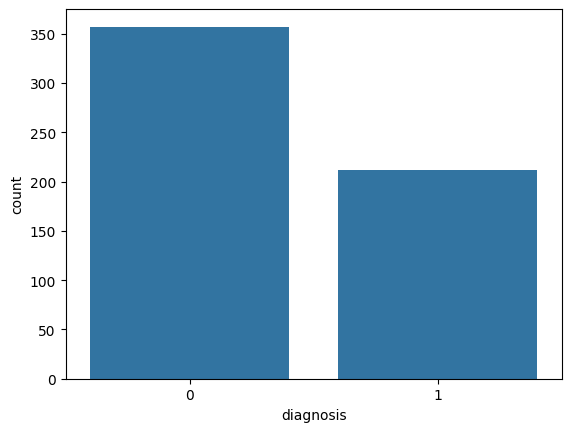

In [ ]:
import seaborn as sns
ax=sns.countplot(x='diagnosis',data=dataset)
plt.show()

Number of Benign:  357
Number of Malignant :  212


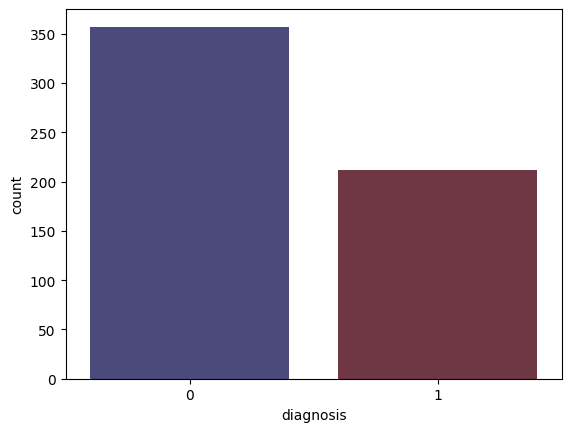

In [ ]:
ax=sns.countplot(x=dataset['diagnosis'], hue=dataset['diagnosis'], label='count', palette='icefire', legend=False)
B,M=dataset['diagnosis'].value_counts()
print('Number of Benign: ',B)
print('Number of Malignant : ',M)
plt.show()

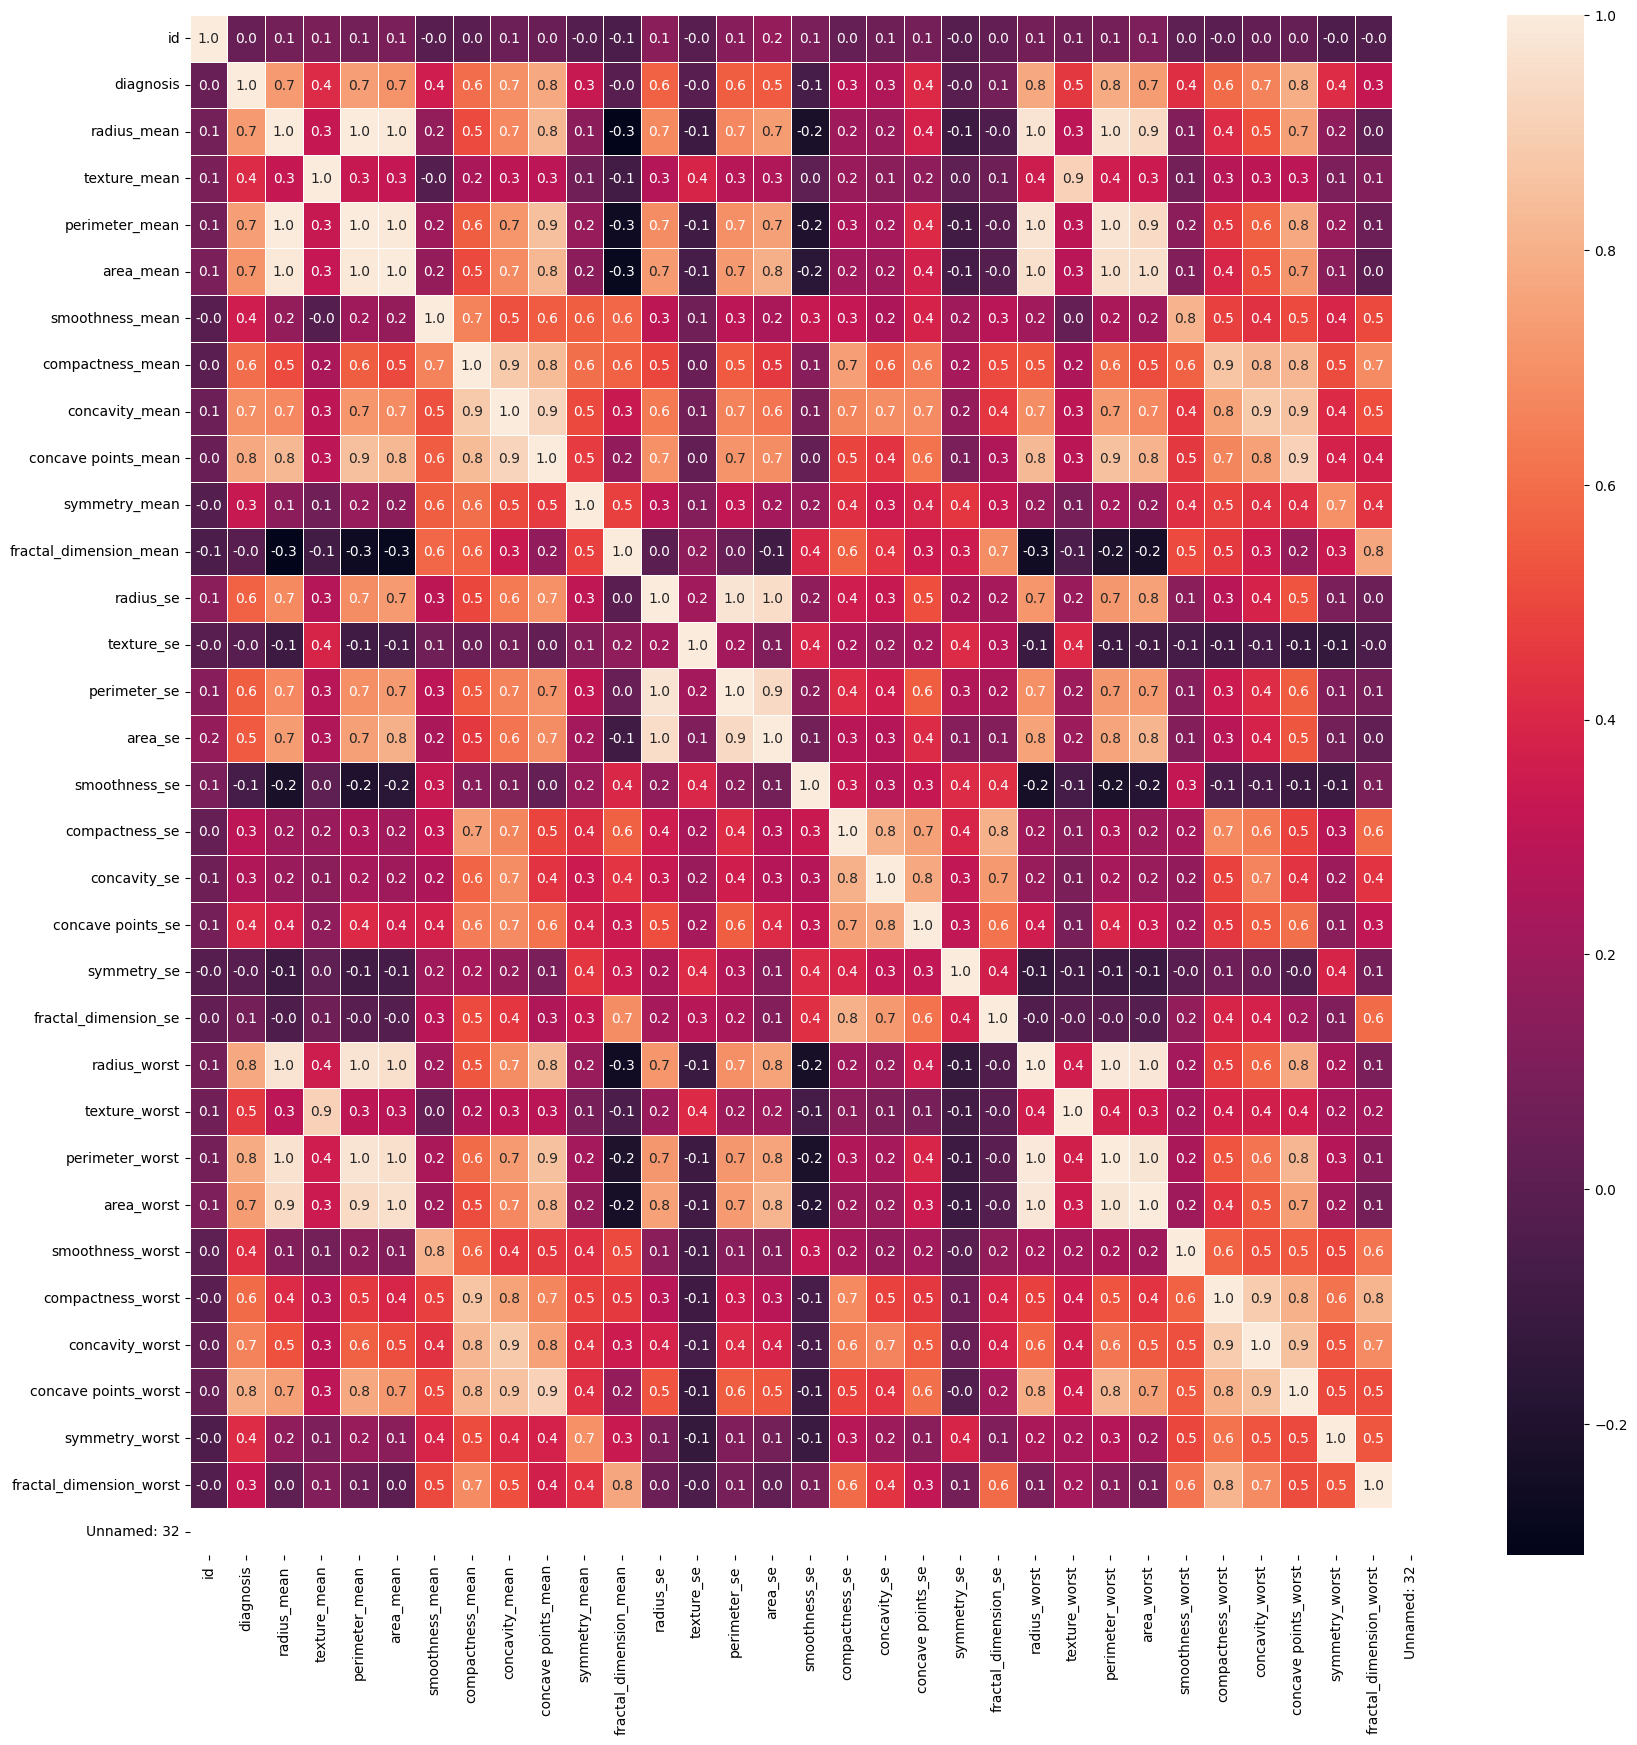

In [ ]:
f,ax=plt.subplots(figsize=(20,20))
sns.heatmap(dataset.corr(),annot=True,linewidth=0.5,fmt='.1f',ax=ax)
plt.show()

In [ ]:
dataset.isnull().sum()
dataset.isna().sum()

,0
id,0
diagnosis,0
radius_mean,0
texture_mean,0
perimeter_mean,0
area_mean,0
smoothness_mean,0
compactness_mean,0
concavity_mean,0
concave points_mean,0


In [ ]:
import pandas as pd

# Get the column names that correspond to the 30 features in 'x'
# Since 'x' contains 'radius_mean' through 'fractal_dimension_worst',
# and 'dataset' currently has 'diagnosis' as the first column,
# these features are from index 1 onwards.
column_names_for_x = dataset.columns[2:-1]

# Create a temporary DataFrame from the first 5 rows of x with appropriate column names
x_df_head = pd.DataFrame(x[:5], columns=column_names_for_x)

display(x_df_head)

,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [ ]:
import pandas as pd

drop_list=['perimeter_mean','area_mean','radius_se','texture_se','concave points_se','perimeter_worst','area_worst','concave points_worst']

# Get the column names that correspond to the current x array
# from the 'dataset' DataFrame, starting from index 2 and excluding the last column.
current_x_columns = dataset.columns[2:-1]

# Convert x (NumPy array) to a DataFrame temporarily to use .drop()
x_df = pd.DataFrame(x, columns=current_x_columns)

# Drop the specified columns
x1 = x_df.drop(columns=drop_list, axis=1).values
x1

array([[17.99   , 10.38   ,  0.1184 , ...,  0.7119 ,  0.4601 ,  0.1189 ],
       [20.57   , 17.77   ,  0.08474, ...,  0.2416 ,  0.275  ,  0.08902],
       [19.69   , 21.25   ,  0.1096 , ...,  0.4504 ,  0.3613 ,  0.08758],
       ...,
       [16.6    , 28.08   ,  0.08455, ...,  0.3403 ,  0.2218 ,  0.0782 ],
       [20.6    , 29.33   ,  0.1178 , ...,  0.9387 ,  0.4087 ,  0.124  ],
       [ 7.76   , 24.54   ,  0.05263, ...,  0.     ,  0.2871 ,  0.07039]])

In [ ]:
# Importing various machine learning models
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB

# Importing metrics to evaluate model performance
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import StratifiedKFold

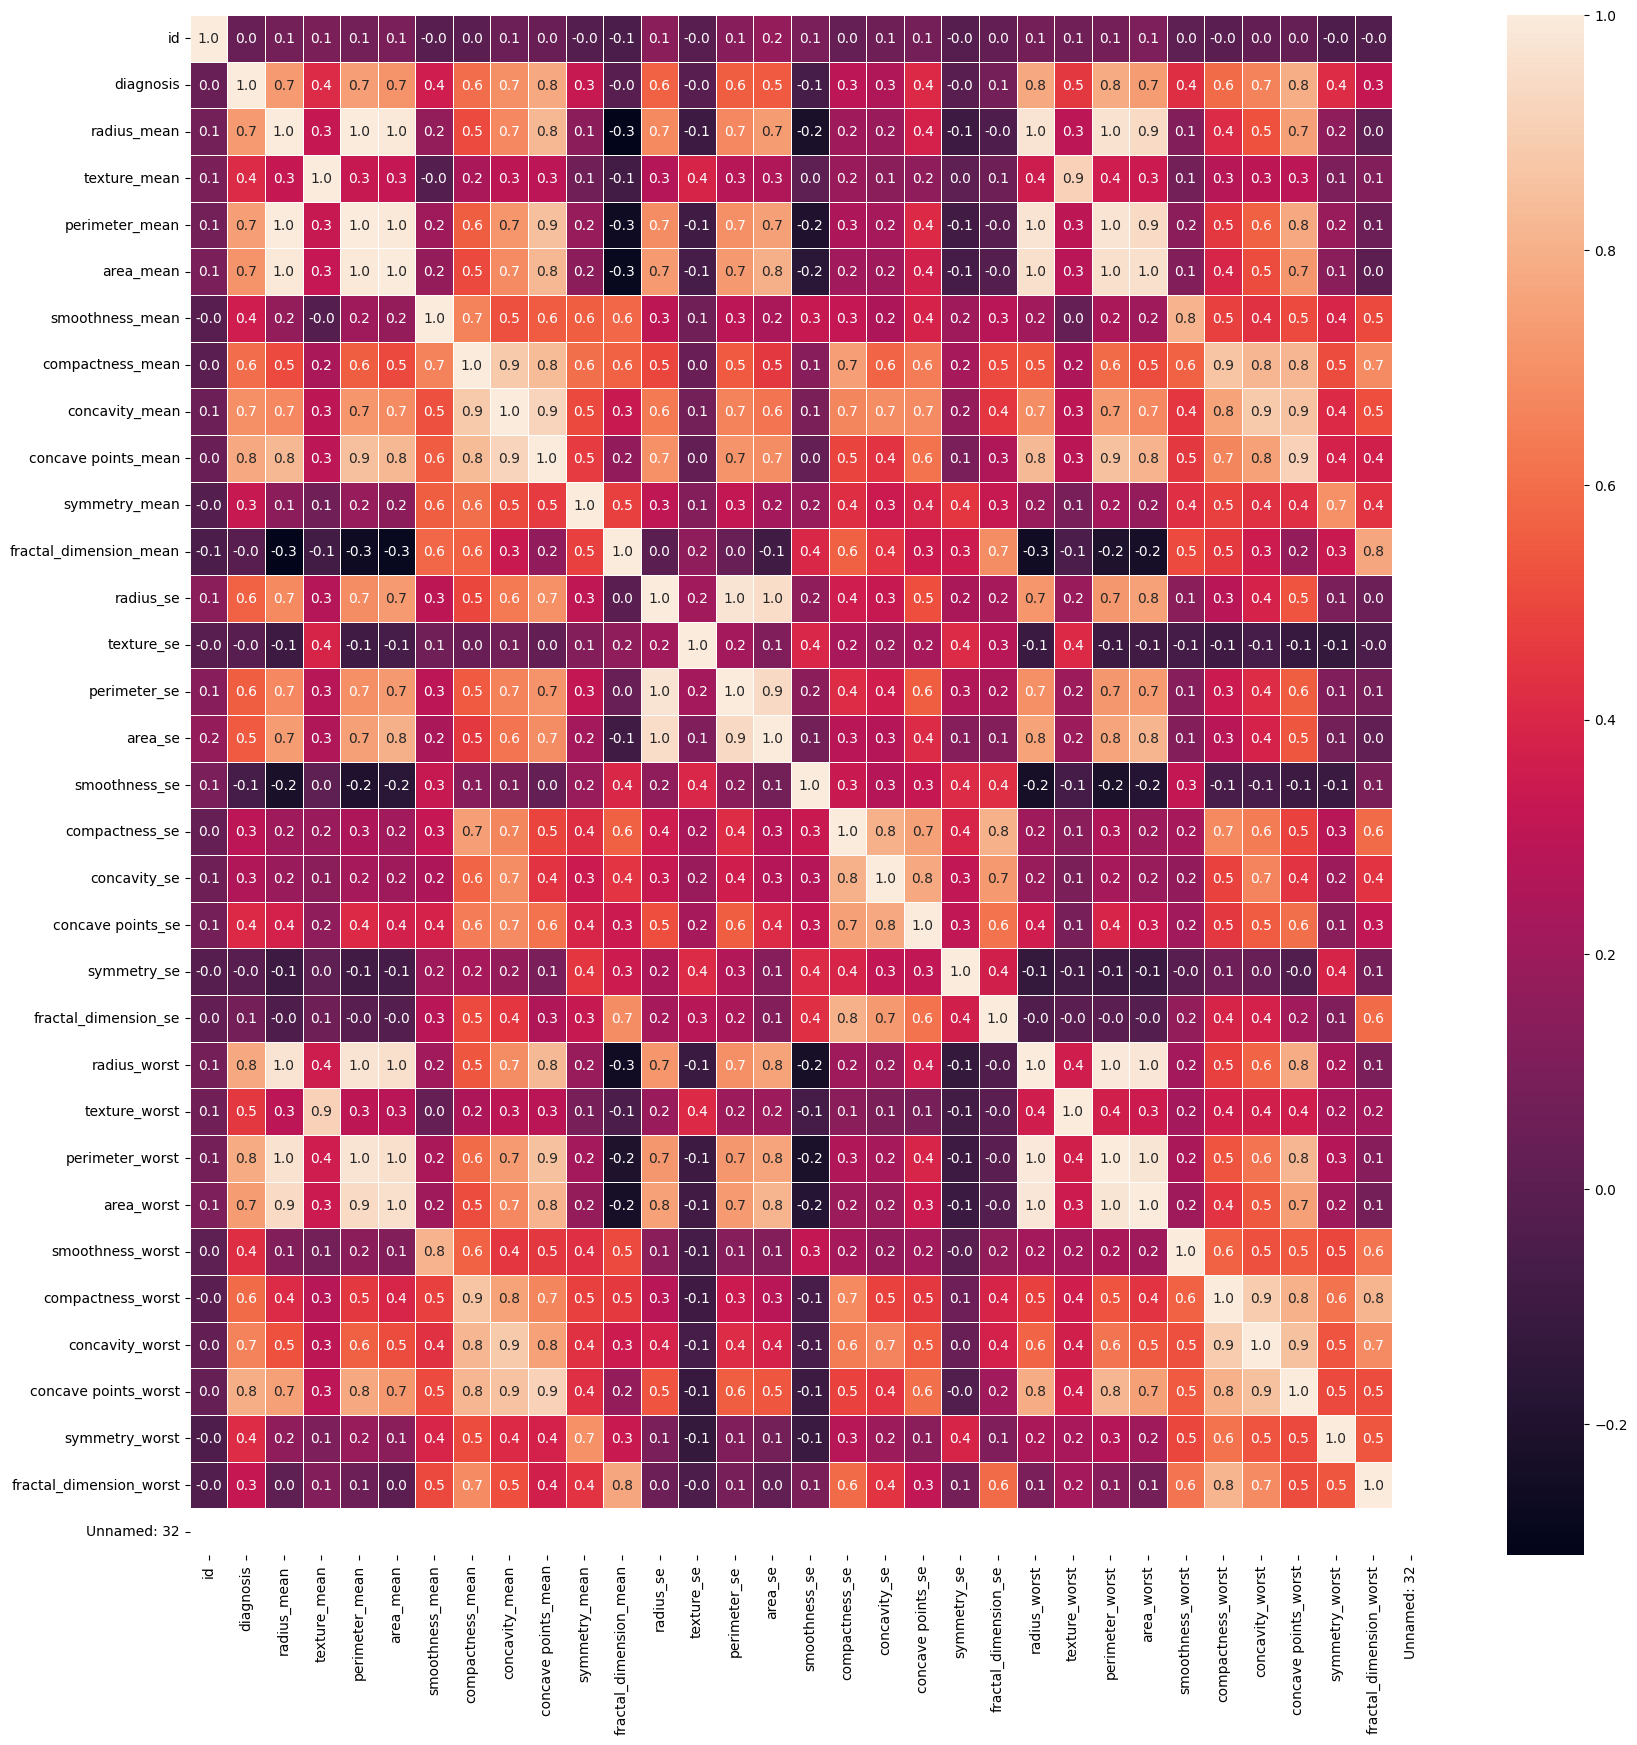

In [ ]:
f,ax=plt.subplots(figsize=(20,20))
sns.heatmap(dataset.corr(),annot=True,linewidth=0.5,fmt='.1f',ax=ax)
plt.show()

In [ ]:
from sklearn.model_selection import train_test_split
# Exclude the 'Unnamed: 32' column which contains NaN values.
# We select all columns from index 2 up to, but not including, the last column.
x = dataset.iloc[:, 2:-1].values
# Explicitly select the 'diagnosis' column which contains binary labels
y = dataset['diagnosis'].values
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.20, random_state = 0)

In [ ]:
# Importing various machine learning models
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB

# Importing metrics to evaluate model performance
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import StratifiedKFold

In [ ]:
# Importing the StandardScaler
from sklearn.preprocessing import StandardScaler

# Scaling the data
scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

# Creating a list of models to evaluate
models = []
models.append(('LDA', LDA()))
models.append(('LR', LogisticRegression()))
models.append(('KNN', KNeighborsClassifier()))
models.append(('SVC', SVC()))
models.append(('DT', DecisionTreeClassifier()))
models.append(('RF', RandomForestClassifier()))
models.append(('NB', GaussianNB()))

LDA: 0.956087
LR: 0.978068
KNN: 0.964879
SVC: 0.975894
DT: 0.916570
RF: 0.958261
NB: 0.949565


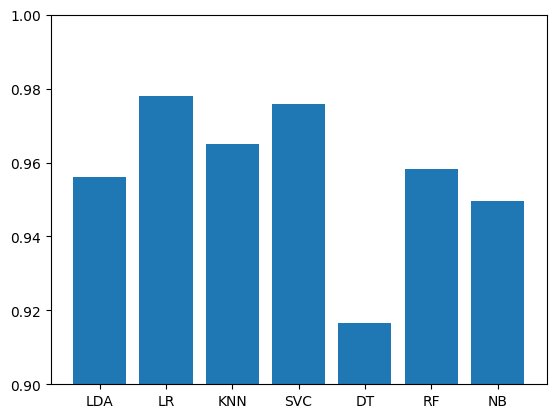

In [ ]:
# Initializing lists to store results
results = []
names = []
res = []

for name, model in models:
  kfold = StratifiedKFold(n_splits=10)
  cv_results = cross_val_score(model, x_train, y_train, cv=kfold, scoring='accuracy')
  results.append(cv_results)
  names.append(name)
  res.append(cv_results.mean())
  msg = "%s: %f" % (name, cv_results.mean())
  print(msg)

# Plotting the accuracy of each model
plt.ylim(0.90 , 1.00)
plt.bar(names, res)
plt.show()


In [ ]:
# Fitting the SupportVectorMachine to the training data
model = SVC()
model.fit(x_train, y_train)

# Making predictions on the test data
predictions = model.predict(x_test)

# Calculating and printing the accuracy of the model
final1 = accuracy_score(y_test, predictions)*100
print(f"Accuracy : {round(final1, 2)}")


Accuracy : 98.25
